In [69]:
import pandas as pd
import numpy as  np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
data = pd.read_csv('customer_analytics_dataset.csv')

In [3]:
data.head()

,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [4]:
data.shape

(5000, 13)

In [5]:
data.isna().sum()

customer_id             0
age                     0
gender                  0
country                 0
avg_order_value       250
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
email_open_rate       250
customer_since          0
loyalty_score           0
churn_risk              0
dtype: int64

In [6]:
data.duplicated().sum()

0

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   object 
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   object 
 3   country             5000 non-null   object 
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   object 
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   object 
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


In [8]:
data.is_fraudulent.value_counts()

0    4871
1     129
Name: is_fraudulent, dtype: int64

# Data Preprocessing aur Feature Engineering(EDA)

In [9]:
data['avg_order_value'] = data['avg_order_value'].fillna(data['avg_order_value'].median())

In [10]:
data['email_open_rate'] = data['email_open_rate'].fillna(data['email_open_rate'].median())

In [11]:
data['customer_since'] = pd.to_datetime(data['customer_since'])

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         5000 non-null   object        
 1   age                 5000 non-null   int64         
 2   gender              5000 non-null   object        
 3   country             5000 non-null   object        
 4   avg_order_value     5000 non-null   float64       
 5   total_orders        5000 non-null   int64         
 6   last_purchase       5000 non-null   int64         
 7   is_fraudulent       5000 non-null   int64         
 8   preferred_category  5000 non-null   object        
 9   email_open_rate     5000 non-null   float64       
 10  customer_since      5000 non-null   datetime64[ns]
 11  loyalty_score       5000 non-null   int64         
 12  churn_risk          5000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(5), obje

In [13]:
data.customer_since.max()

Timestamp('2025-06-28 00:00:00')

In [14]:
data['customer_tenure_days'] = (data.customer_since.max() - data['customer_since']).dt.days

In [15]:
data = data.drop('customer_since',axis=1)

In [16]:
data = data.drop('customer_id',axis=1)

In [17]:
data.head()

,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_tenure_days
0,30,Female,Brazil,101.08,8,176,1,Beauty,25.60,50,0.20,388
1,53,Female,USA,90.39,10,88,0,Electronics,12.30,37,0.34,495
2,73,Male,Australia,83.28,6,203,0,Sports,50.95,65,0.05,438
3,30,Other,Japan,109.90,9,346,1,Electronics,42.90,93,0.19,1816
4,29,Female,Canada,269.38,16,342,0,Fashion,5.30,79,0.15,80


In [18]:
data = pd.get_dummies(data,columns=['preferred_category','country','gender'],drop_first=True)
data

,age,avg_order_value,total_orders,last_purchase,is_fraudulent,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,preferred_category_Electronics,...,country_Canada,country_China,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,gender_Male,gender_Other
0,30,101.08,8,176,1,25.60,50,0.20,388,0,...,0,0,0,0,0,0,0,0,0,0
1,53,90.39,10,88,0,12.30,37,0.34,495,1,...,0,0,0,0,0,0,0,1,0,0
2,73,83.28,6,203,0,50.95,65,0.05,438,0,...,0,0,0,0,0,0,0,0,1,0
3,30,109.90,9,346,1,42.90,93,0.19,1816,1,...,0,0,0,0,0,1,0,0,0,1
4,29,269.38,16,342,0,5.30,79,0.15,80,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,49,132.16,9,306,0,20.90,13,0.33,1715,1,...,0,0,0,0,0,0,1,0,0,0
4996,23,47.81,10,296,0,50.95,66,0.22,250,0,...,0,0,0,0,0,0,1,0,0,0
4997,79,224.97,16,84,0,92.90,56,0.23,958,0,...,0,0,0,0,0,1,0,0,1,0
4998,62,220.33,8,254,0,83.80,47,0.09,761,0,...,0,0,0,0,0,0,0,1,1,0


In [19]:
data.shape

(5000, 24)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             5000 non-null   int64  
 1   avg_order_value                 5000 non-null   float64
 2   total_orders                    5000 non-null   int64  
 3   last_purchase                   5000 non-null   int64  
 4   is_fraudulent                   5000 non-null   int64  
 5   email_open_rate                 5000 non-null   float64
 6   loyalty_score                   5000 non-null   int64  
 7   churn_risk                      5000 non-null   float64
 8   customer_tenure_days            5000 non-null   int64  
 9   preferred_category_Electronics  5000 non-null   uint8  
 10  preferred_category_Fashion      5000 non-null   uint8  
 11  preferred_category_Home         5000 non-null   uint8  
 12  preferred_category_Sports       50

# Train-Test Split

In [21]:
X = data.drop('is_fraudulent',axis=1)
y = data.is_fraudulent

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [23]:
y_train.value_counts()

0    3410
1      90
Name: is_fraudulent, dtype: int64

# SMOTE

In [24]:
from imblearn.over_sampling import SMOTE

In [25]:
smote = SMOTE()

In [26]:
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [27]:
y_train_res.value_counts()

0    3410
1    3410
Name: is_fraudulent, dtype: int64

# StandardScaling

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
num_col = ['age','avg_order_value','total_orders','last_purchase','email_open_rate','loyalty_score',
          'churn_risk','customer_tenure_days']

In [30]:
std =  StandardScaler()

In [31]:
X_train_res[num_col] = std.fit_transform(X_train_res[num_col])

In [32]:
X_train_res.head()

,age,avg_order_value,total_orders,last_purchase,email_open_rate,loyalty_score,churn_risk,customer_tenure_days,preferred_category_Electronics,preferred_category_Fashion,...,country_Canada,country_China,country_France,country_Germany,country_India,country_Japan,country_UK,country_USA,gender_Male,gender_Other
0,1.367900,-0.646750,-1.007255,0.983999,-0.609734,0.294169,-0.908764,1.188500,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0.200267,-0.140860,0.445373,0.846573,1.746224,-1.706209,-0.631845,-1.512672,0,0,...,0,0,0,0,0,0,0,0,1,0
2,-0.905911,-1.032165,-0.644098,1.101793,0.497092,-0.298536,1.306588,0.315322,1,0,...,0,0,0,0,0,1,0,0,1,0
3,-1.827726,-0.130806,0.445373,1.131241,-1.277783,-1.224637,0.060452,1.429866,0,0,...,0,0,1,0,0,0,0,0,0,0
4,-1.581908,0.923837,2.987474,-0.272467,-0.038533,1.664798,1.652737,-0.257923,0,0,...,0,0,0,0,0,0,1,0,1,0


# Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
model = LogisticRegression(random_state=42)

In [35]:
model.fit(X_train_res,y_train_res)

LogisticRegression(random_state=42)

In [36]:
y_pred = model.predict(X_train_res)

In [37]:
y_pred_test = model.predict(X_test)

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

In [39]:
print(classification_report(y_train_res,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3410
           1       0.90      0.93      0.92      3410

    accuracy                           0.91      6820
   macro avg       0.91      0.91      0.91      6820
weighted avg       0.91      0.91      0.91      6820



In [40]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.14      0.24      1461
           1       0.03      0.87      0.05        39

    accuracy                           0.16      1500
   macro avg       0.50      0.51      0.15      1500
weighted avg       0.95      0.16      0.24      1500



# Decision Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
dt_model = DecisionTreeClassifier()

In [43]:
dt_model.fit(X_train_res,y_train_res)

DecisionTreeClassifier()

In [44]:
y_dt_pred = dt_model.predict(X_train_res)

In [45]:
y_dt_test_pred = dt_model.predict(X_test)

In [46]:
print(classification_report(y_train_res,y_dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3410
           1       1.00      1.00      1.00      3410

    accuracy                           1.00      6820
   macro avg       1.00      1.00      1.00      6820
weighted avg       1.00      1.00      1.00      6820



In [47]:
print(classification_report(y_test,y_dt_test_pred ))

              precision    recall  f1-score   support

           0       0.97      0.56      0.71      1461
           1       0.03      0.46      0.05        39

    accuracy                           0.55      1500
   macro avg       0.50      0.51      0.38      1500
weighted avg       0.95      0.55      0.69      1500



# Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
rf_model = RandomForestClassifier(n_estimators=100)

In [50]:
rf_model.fit(X_train_res,y_train_res)

RandomForestClassifier()

In [51]:
y_rf_test_pred = rf_model.predict(X_test)

In [52]:
print(classification_report(y_test,y_rf_test_pred ))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1461
           1       0.00      0.00      0.00        39

    accuracy                           0.97      1500
   macro avg       0.49      0.50      0.49      1500
weighted avg       0.95      0.97      0.96      1500



/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

# XGBOOST

In [53]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [54]:
from xgboost import XGBClassifier

In [55]:
xgb_model = XGBClassifier(XGBClassifieruse_label_encoder=False, eval_metric='logloss')

In [56]:
xgb_model.fit(X_train_res,y_train_res)

/home/4348cc34-6565-4da0-8cfe-d853b52489ea/.local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [08:30:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "XGBClassifieruse_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(XGBClassifieruse_label_encoder=False, base_score=None,
              booster=None, callbacks=None, colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
y_xgb_test_pred = rf_model.predict(X_test)

In [83]:
print(classification_report(y_test,y_xgb_test_pred ))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1461
           1       0.00      0.00      0.00        39

    accuracy                           0.97      1500
   macro avg       0.49      0.50      0.49      1500
weighted avg       0.95      0.97      0.96      1500



/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

In [59]:
xgb_new = XGBClassifier(scale_pos_weight=30, eval_metric='logloss')

In [61]:
xgb_new.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [62]:
xgb_new_pred = xgb_new.predict(X_test)
print(classification_report(y_test, xgb_new_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1461
           1       0.33      0.03      0.05        39

    accuracy                           0.97      1500
   macro avg       0.65      0.51      0.52      1500
weighted avg       0.96      0.97      0.96      1500



In [63]:
y_probs = xgb_new.predict_proba(X_test)[:,1]

In [67]:
y_pred_custom = (y_probs >= 0.05).astype(int)

In [68]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1461
           1       0.04      0.10      0.06        39

    accuracy                           0.92      1500
   macro avg       0.51      0.52      0.51      1500
weighted avg       0.95      0.92      0.93      1500



# JItne bhi algurithum used ka gye ha un sab me sab se behter SMOTE + Decision Tree Fraud Detection kia ha to is hi lia sirf us hi ka visual plot banya ha 

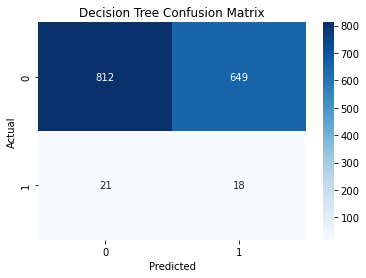

In [71]:
cm = confusion_matrix(y_test, y_dt_test_pred )
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
data.to_csv('')